In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

df = pd.read_csv('../data/churn_clean.csv')
print("Données chargées ✅")

Données chargées ✅


In [3]:
df_model = df.copy()

# Identifier les colonnes texte
colonnes_texte = df_model.select_dtypes(include='str').columns
print(f"Colonnes à encoder : {list(colonnes_texte)}")

# Encodage automatique
le = LabelEncoder()
for col in colonnes_texte:
    df_model[col] = le.fit_transform(df_model[col])

print("Encodage terminé ✅")
df_model.head()

Colonnes à encoder : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encodage terminé ✅


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [4]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entraînement : {X_train.shape[0]} lignes")
print(f"Test         : {X_test.shape[0]} lignes")

Entraînement : 5625 lignes
Test         : 1407 lignes


In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # important car le churn est minoritaire
)

model.fit(X_train, y_train)
print("Modèle entraîné ✅")

Modèle entraîné ✅


In [6]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred,
      target_names=['Fidèle', 'Churner']))

auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC : {auc:.3f}")

=== Rapport de classification ===
              precision    recall  f1-score   support

      Fidèle       0.82      0.89      0.86      1033
     Churner       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407

AUC-ROC : 0.813


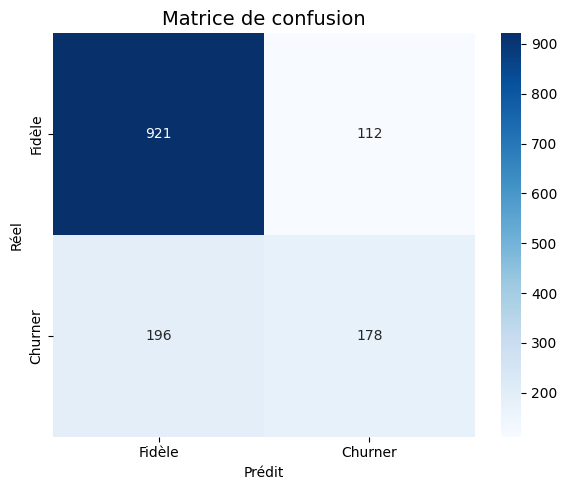

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fidèle', 'Churner'],
            yticklabels=['Fidèle', 'Churner'], ax=ax)
ax.set_title("Matrice de confusion", fontsize=14)
ax.set_ylabel("Réel")
ax.set_xlabel("Prédit")
plt.tight_layout()
plt.savefig('../data/graph6_confusion_matrix.png', dpi=150)
plt.show()

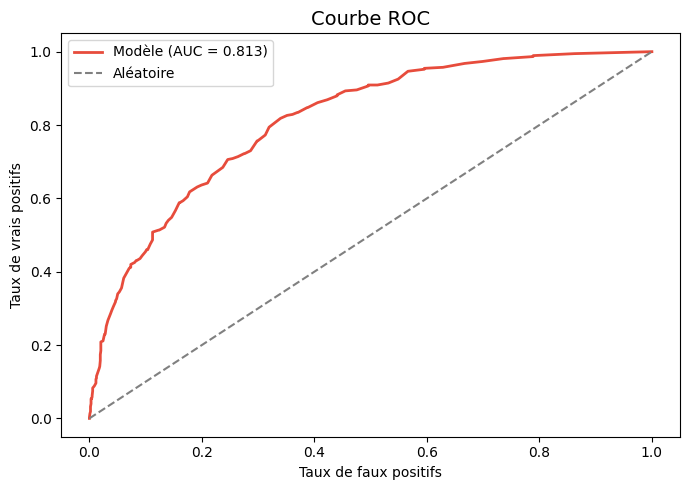

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#e74c3c', lw=2,
        label=f'Modèle (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Aléatoire')
ax.set_title("Courbe ROC", fontsize=14)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend()
plt.tight_layout()
plt.savefig('../data/graph7_roc_curve.png', dpi=150)
plt.show()

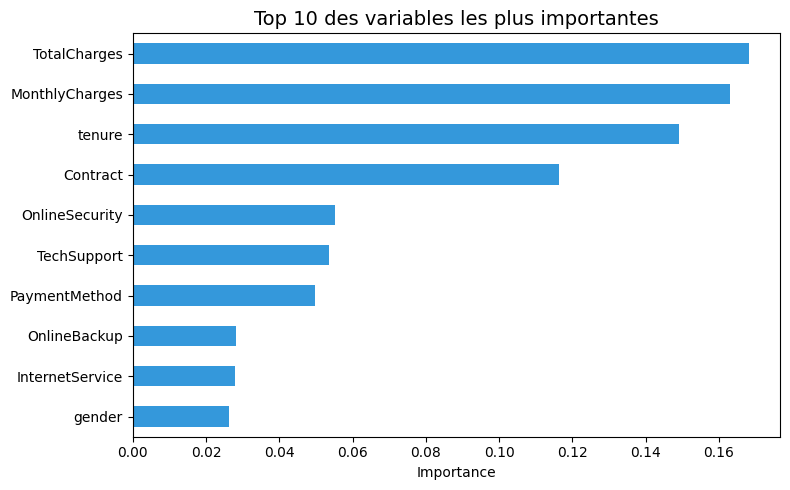

In [9]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(color='#3498db', ax=ax)
ax.invert_yaxis()
ax.set_title("Top 10 des variables les plus importantes", fontsize=14)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig('../data/graph8_feature_importance.png', dpi=150)
plt.show()

In [10]:
print("""
=== RECOMMANDATIONS BUSINESS ===

1. PRIORITÉ HAUTE — Cibler les clients mois/mois avec < 6 mois d'ancienneté
   → Offrir une remise pour passer en contrat annuel

2. PRIORITÉ HAUTE — Surveiller les clients avec MonthlyCharges > 70$
   → Proposer un audit de leur offre pour réduire la facture

3. PRIORITÉ MOYENNE — Créer un score de risque mensuel
   → Utiliser ce modèle en production pour alerter le service client

4. MESURE DE SUCCÈS — Réduire le churn de 26% à < 20% en 6 mois
   → Économie estimée : X k$ de revenus préservés
""")


=== RECOMMANDATIONS BUSINESS ===

1. PRIORITÉ HAUTE — Cibler les clients mois/mois avec < 6 mois d'ancienneté
   → Offrir une remise pour passer en contrat annuel

2. PRIORITÉ HAUTE — Surveiller les clients avec MonthlyCharges > 70$
   → Proposer un audit de leur offre pour réduire la facture

3. PRIORITÉ MOYENNE — Créer un score de risque mensuel
   → Utiliser ce modèle en production pour alerter le service client

4. MESURE DE SUCCÈS — Réduire le churn de 26% à < 20% en 6 mois
   → Économie estimée : X k$ de revenus préservés



In [11]:
# Export d'un fichier enrichi pour Power BI
df_powerbi = df.copy()

# Ajouter le score de risque prédit par le modèle
df_encoded = df_model.drop(columns=['Churn'])
df_powerbi['Score_Churn'] = model.predict_proba(df_encoded)[:, 1]
df_powerbi['Score_Churn'] = df_powerbi['Score_Churn'].round(3)

# Ajouter le segment de risque
df_powerbi['Segment_Risque'] = pd.cut(
    df_powerbi['Score_Churn'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Faible', 'Moyen', 'Élevé']
)

df_powerbi.to_csv('../data/churn_powerbi.csv', index=False)
print("Fichier Power BI exporté ✅")

Fichier Power BI exporté ✅
